# 1. Top điểm nóng gọi xe

--- KHỐI 1: TẢI DỮ LIỆU & TOP 20 ĐIỂM NÓNG GỌI XE (HOTSPOTS) ---
Đã tải thành công 3,499,217 dòng dữ liệu.



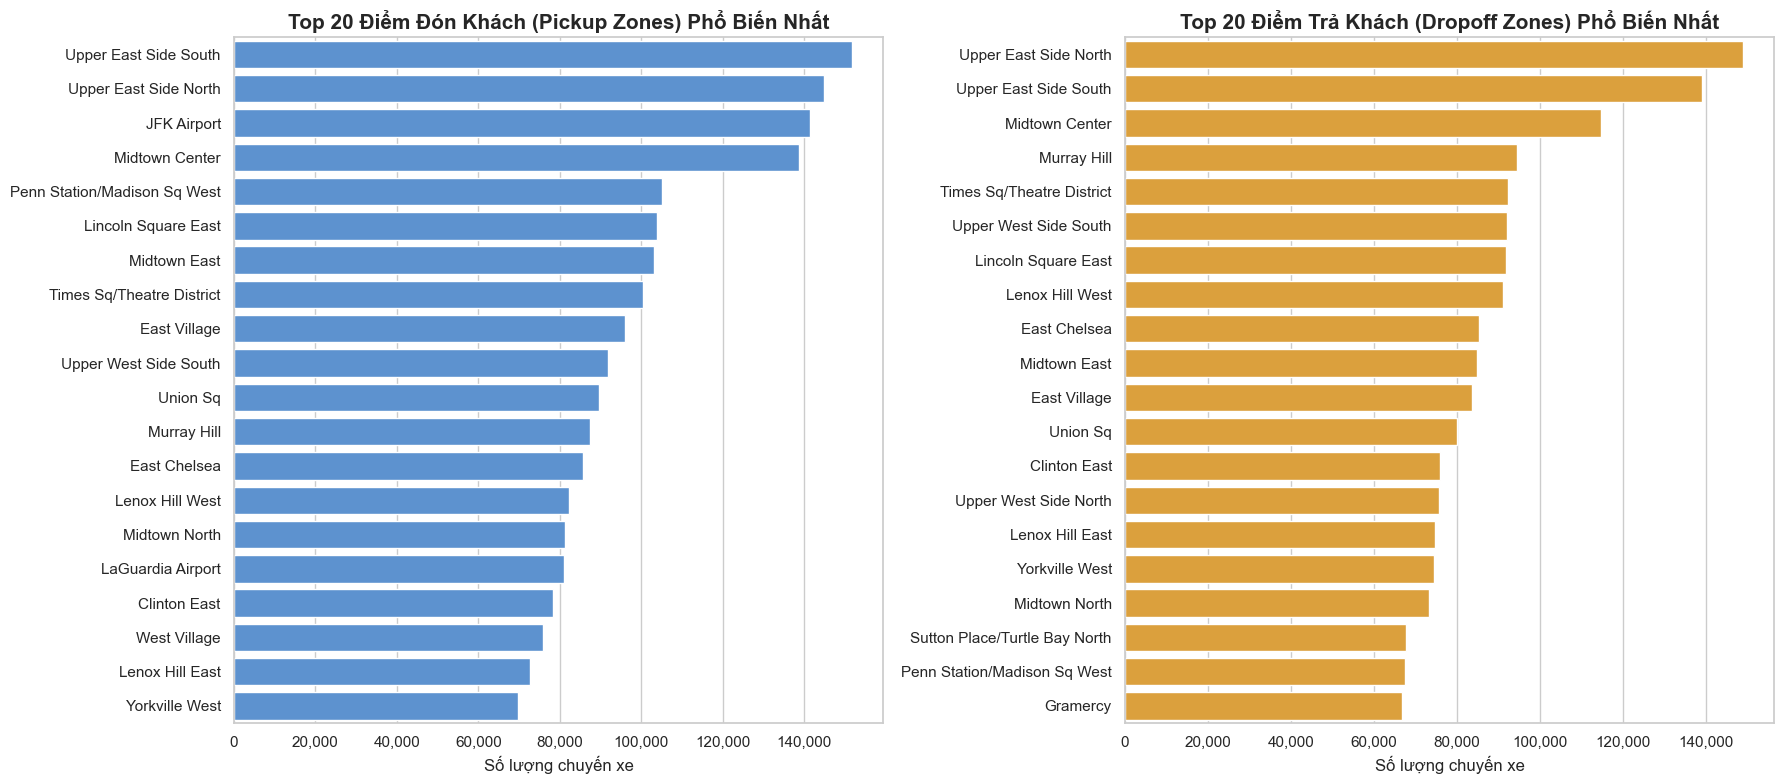

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tùy chỉnh giao diện biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")

print("--- KHỐI 1: TẢI DỮ LIỆU & TOP 20 ĐIỂM NÓNG GỌI XE (HOTSPOTS) ---")

# 1. Tải dữ liệu
clean_data_path = r'../../data/yellow_tripdata_2026-01_CLEANED.parquet'
df = pd.read_parquet(clean_data_path)
print(f"Đã tải thành công {len(df):,} dòng dữ liệu.\n")

# 2. Lấy Top 20 Pickup Zones (Điểm đón khách)
top20_pu = df['pu_Zone'].value_counts().head(20).reset_index()
top20_pu.columns = ['Pickup Zone', 'Số lượng chuyến']

# 3. Lấy Top 20 Dropoff Zones (Điểm trả khách)
top20_do = df['do_Zone'].value_counts().head(20).reset_index()
top20_do.columns = ['Dropoff Zone', 'Số lượng chuyến']

# 4. Vẽ biểu đồ 2 bảng song song
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Biểu đồ Top 20 Pickup
sns.barplot(data=top20_pu, y='Pickup Zone', x='Số lượng chuyến', ax=ax[0], color='#4A90E2')
ax[0].set_title('Top 20 Điểm Đón Khách (Pickup Zones) Phổ Biến Nhất', fontsize=15, fontweight='bold')
ax[0].set_xlabel('Số lượng chuyến xe', fontsize=12)
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Biểu đồ Top 20 Dropoff
sns.barplot(data=top20_do, y='Dropoff Zone', x='Số lượng chuyến', ax=ax[1], color='#F5A623')
ax[1].set_title('Top 20 Điểm Trả Khách (Dropoff Zones) Phổ Biến Nhất', fontsize=15, fontweight='bold')
ax[1].set_xlabel('Số lượng chuyến xe', fontsize=12)
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


> **📝 Góc nhìn Kinh doanh (Business Insights):**
> * **Sự thống trị của Manhattan:** Gần như 100% các điểm Đón và Trả khách nhộn nhịp nhất đều nằm lọt thỏm trong khu vực nội đô Manhattan (đặc biệt là Upper East Side, Midtown, Times Square). 
> * **Nghịch lý Sân bay:** Sân bay JFK lọt vào tận Top 3 Điểm Đón, nhưng lại hoàn toàn "mất tích" khỏi Top 20 Điểm Trả. Điều này cho thấy sự mất cân bằng nghiêm trọng về luồng di chuyển.


# 2. Ma trận luồng di chuyển

--- KHỐI 2: MA TRẬN LUỒNG DI CHUYỂN (ORIGIN - DESTINATION FLOW) ---
Top 10 Tuyến đường di chuyển đông đúc nhất:


,pu_Zone,do_Zone,trips
35697,Upper East Side South,Upper East Side North,23136
35466,Upper East Side North,Upper East Side South,20031
35465,Upper East Side North,Upper East Side North,15868
35698,Upper East Side South,Upper East Side South,14706
23635,Midtown Center,Upper East Side South,9913
35627,Upper East Side South,Midtown Center,9101
20675,Lincoln Square East,Upper West Side South,8663
36134,Upper West Side South,Upper West Side North,8457
23634,Midtown Center,Upper East Side North,8217
20439,Lenox Hill West,Upper East Side North,8166


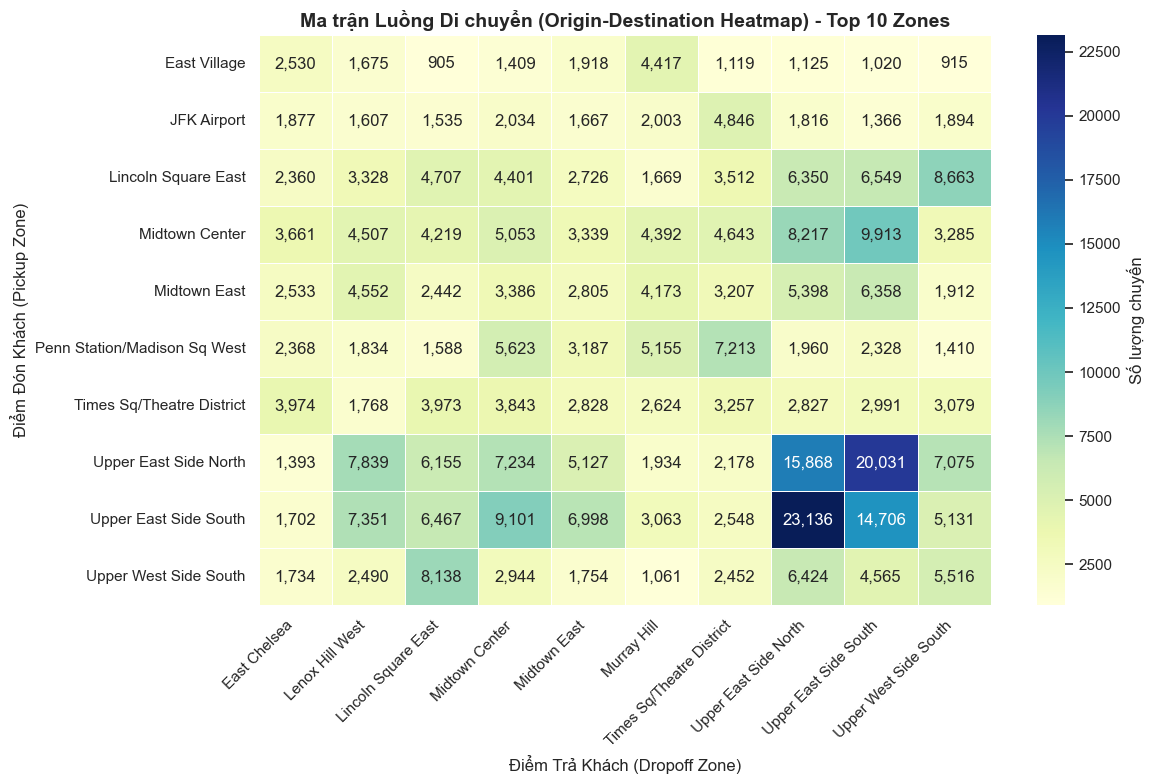

In [2]:
print("--- KHỐI 2: MA TRẬN LUỒNG DI CHUYỂN (ORIGIN - DESTINATION FLOW) ---")

# 1. Tìm các Tuyến đường (Routes) phổ biến nhất
routes = df.groupby(['pu_Zone', 'do_Zone']).size().reset_index(name='trips')
routes = routes.sort_values(by='trips', ascending=False)
print("Top 10 Tuyến đường di chuyển đông đúc nhất:")
display(routes.head(10))

# 2. Vẽ Bản đồ nhiệt (Heatmap) ma trận di chuyển của Top 10 Khu vực
# Lấy danh sách 10 khu vực đón khách nhiều nhất
top10_pu_names = top20_pu['Pickup Zone'].head(10).tolist()
# Lấy danh sách 10 khu vực trả khách nhiều nhất
top10_do_names = top20_do['Dropoff Zone'].head(10).tolist()

# Lọc dữ liệu chỉ giữ lại các cuốc xe đi lại giữa 10 khu vực này để ma trận không bị quá to
matrix_df = routes[(routes['pu_Zone'].isin(top10_pu_names)) & (routes['do_Zone'].isin(top10_do_names))]

# Tạo bảng Pivot (Ma trận 2 chiều: Dòng là Điểm đón, Cột là Điểm đến)
od_matrix = matrix_df.pivot(index='pu_Zone', columns='do_Zone', values='trips').fillna(0)

# Vẽ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(od_matrix, cmap='YlGnBu', annot=True, fmt=',.0f', linewidths=.5, cbar_kws={'label': 'Số lượng chuyến'})
plt.title('Ma trận Luồng Di chuyển (Origin-Destination Heatmap) - Top 10 Zones', fontsize=14, fontweight='bold')
plt.xlabel('Điểm Trả Khách (Dropoff Zone)', fontsize=12)
plt.ylabel('Điểm Đón Khách (Pickup Zone)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **📝 Góc nhìn Kinh doanh (Business Insights):**
> * **Luồng di chuyển Intra-zone (Nội bộ):** Trái với suy nghĩ taxi thường chạy đường dài, 2 tuyến đường "hái ra tiền" nhiều nhất lại là những chuyến đi cực kỳ ngắn loanh quanh trong khu nhà giàu Upper East Side (Từ khu South sang khu North và ngược lại).
> * Khách hàng ở đây thà gọi Taxi để đi ăn sáng, đi siêu thị vài block đường thay vì phải đi bộ.


# 3. Phân tích sân bay và chiều di chuyển sân bay


--- KHỐI 3: PHÂN TÍCH SÂN BAY (AIRPORT ANALYSIS) ---
Tổng số cuốc Sân bay: 268,649 chuyến (7.68%)
Tổng số cuốc Nội đô: 3,230,568 chuyến (92.32%)

Bảng thống kê Trung bình:


,trip_type,fare_amount,trip_distance
0,Nội đô (City),18.17,2.69
1,Sân bay (Airport),56.32,13.12


C:\Users\minhh\AppData\Local\Temp\ipykernel_27716\427070560.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airport_stats, x='trip_type', y='fare_amount', ax=ax[0], palette=['#F5A623', '#4A90E2'])
C:\Users\minhh\AppData\Local\Temp\ipykernel_27716\427070560.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airport_stats, x='trip_type', y='trip_distance', ax=ax[1], palette=['#F5A623', '#4A90E2'])


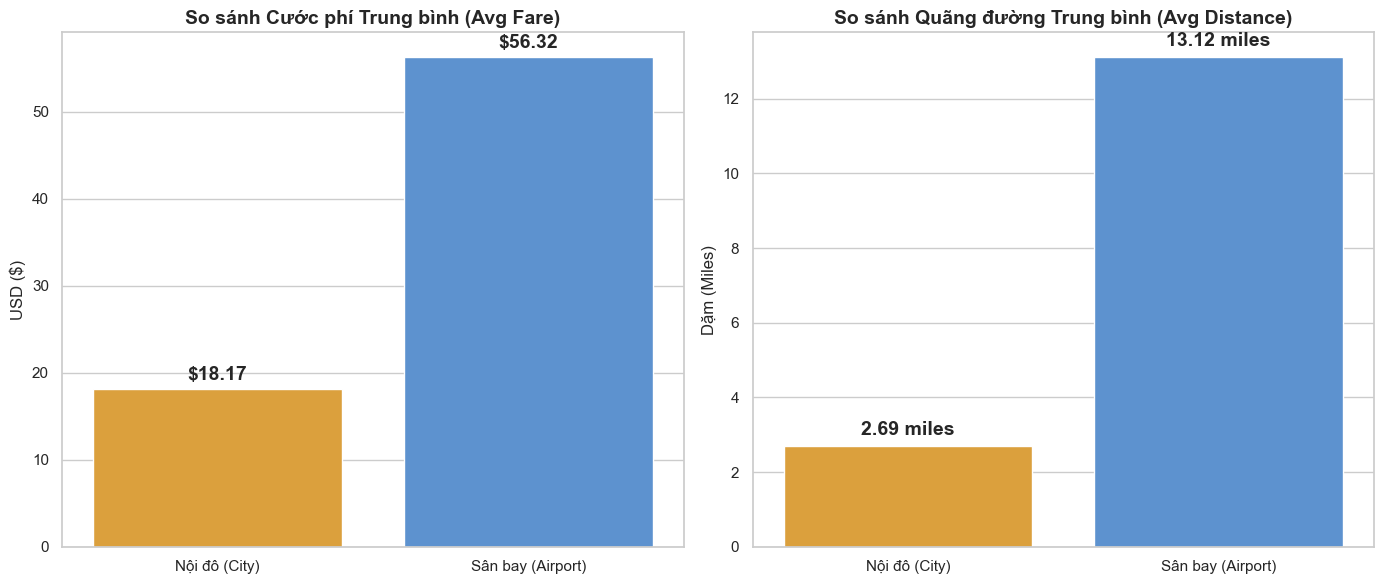

In [3]:
print("--- KHỐI 3: PHÂN TÍCH SÂN BAY (AIRPORT ANALYSIS) ---")

# 1. Xác định các cuốc xe Sân bay (Có chữ 'Airport' ở Điểm đón HOẶC Điểm đến)
# Lưu ý: Cú pháp này bao trọn cả JFK, LaGuardia và Newark
is_airport = df['pu_Zone'].str.contains('Airport', case=False, na=False) | \
             df['do_Zone'].str.contains('Airport', case=False, na=False)

# Tạo cột phân loại chuyến đi
df['trip_type'] = 'Nội đô (City)'
df.loc[is_airport, 'trip_type'] = 'Sân bay (Airport)'

# 2. Tính % Trips liên quan đến Sân bay
trip_type_counts = df['trip_type'].value_counts()
airport_pct = (trip_type_counts['Sân bay (Airport)'] / len(df)) * 100
print(f"Tổng số cuốc Sân bay: {trip_type_counts['Sân bay (Airport)']:,.0f} chuyến ({airport_pct:.2f}%)")
print(f"Tổng số cuốc Nội đô: {trip_type_counts['Nội đô (City)']:,.0f} chuyến ({100 - airport_pct:.2f}%)\n")

# 3. Tính Giá tiền (Fare) và Quãng đường (Distance) trung bình
airport_stats = df.groupby('trip_type')[['fare_amount', 'trip_distance']].mean().round(2).reset_index()
print("Bảng thống kê Trung bình:")
display(airport_stats)

# 4. Vẽ biểu đồ so sánh trực quan
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ Cước phí
sns.barplot(data=airport_stats, x='trip_type', y='fare_amount', ax=ax[0], palette=['#F5A623', '#4A90E2'])
ax[0].set_title('So sánh Cước phí Trung bình (Avg Fare)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('USD ($)', fontsize=12)
ax[0].set_xlabel('')
for i, v in enumerate(airport_stats['fare_amount']):
    ax[0].text(i, v + 1, f"${v}", ha='center', fontweight='bold', fontsize=14)

# Biểu đồ Quãng đường
sns.barplot(data=airport_stats, x='trip_type', y='trip_distance', ax=ax[1], palette=['#F5A623', '#4A90E2'])
ax[1].set_title('So sánh Quãng đường Trung bình (Avg Distance)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Dặm (Miles)', fontsize=12)
ax[1].set_xlabel('')
for i, v in enumerate(airport_stats['trip_distance']):
    ax[1].text(i, v + 0.3, f"{v} miles", ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()


--- KHỐI 3: PHÂN TÍCH CHIỀU DI CHUYỂN SÂN BAY ---
Bảng thống kê Chiều di chuyển:


,Hướng di chuyển,Số lượng chuyến,Phần trăm (%)
0,Từ Sân bay về Nội đô\n(Airport -> City),215163,80.09
1,Từ Nội đô ra Sân bay\n(City -> Airport),46093,17.16
2,Nội bộ Sân bay\n(Airport -> Airport),7393,2.75


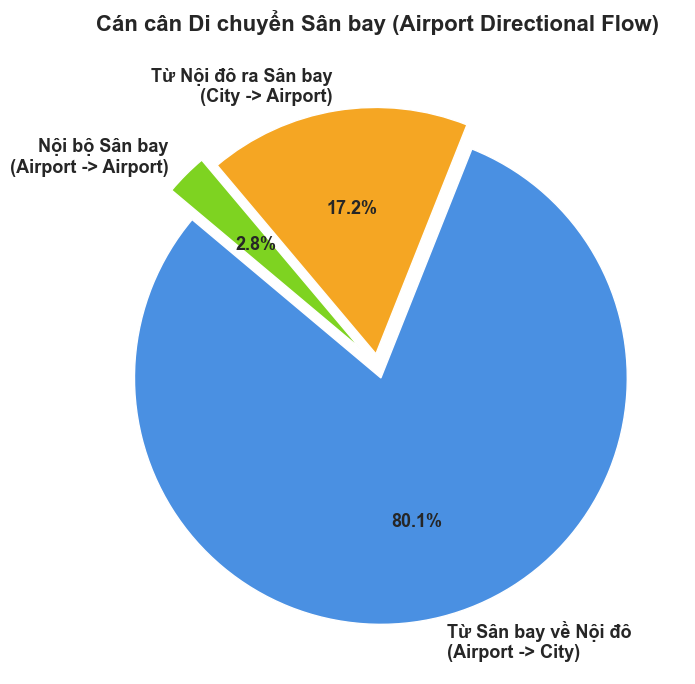

In [4]:
print("--- KHỐI 3: PHÂN TÍCH CHIỀU DI CHUYỂN SÂN BAY ---")

# Lọc các cuốc xe có liên quan đến Sân bay (đã xác định ở Khối 3)
airport_trips = df[is_airport].copy()

# Định nghĩa hàm phân loại hướng đi
def get_direction(row):
    pu_is_airport = 'airport' in str(row['pu_Zone']).lower()
    do_is_airport = 'airport' in str(row['do_Zone']).lower()
    
    if pu_is_airport and not do_is_airport:
        return 'Từ Sân bay về Nội đô\n(Airport -> City)'
    elif not pu_is_airport and do_is_airport:
        return 'Từ Nội đô ra Sân bay\n(City -> Airport)'
    else:
        return 'Nội bộ Sân bay\n(Airport -> Airport)'

# Áp dụng hàm để tạo cột Hướng đi
airport_trips['direction'] = airport_trips.apply(get_direction, axis=1)

# Đếm số lượng theo hướng đi
direction_counts = airport_trips['direction'].value_counts().reset_index()
direction_counts.columns = ['Hướng di chuyển', 'Số lượng chuyến']

# Tính phần trăm
total_airport_trips = len(airport_trips)
direction_counts['Phần trăm (%)'] = (direction_counts['Số lượng chuyến'] / total_airport_trips * 100).round(2)

print("Bảng thống kê Chiều di chuyển:")
display(direction_counts)

# Vẽ biểu đồ Tròn (Pie Chart) để thể hiện Cán cân tỷ trọng
plt.figure(figsize=(8, 8))
plt.pie(direction_counts['Số lượng chuyến'], labels=direction_counts['Hướng di chuyển'], 
        autopct='%1.1f%%', startangle=140, colors=['#4A90E2', '#F5A623', '#7ED321'],
        textprops={'fontsize': 13, 'fontweight': 'bold'}, explode=(0.05, 0.05, 0.1))
plt.title('Cán cân Di chuyển Sân bay (Airport Directional Flow)', fontsize=16, fontweight='bold', pad=20)
plt.show()


> **📝 Góc nhìn Kinh doanh (Business Insights):**
> * **Mỏ vàng của tài xế:** Dù lượng cuốc xe Sân bay chiếm tỷ trọng không cao, nhưng nó mang lại doanh thu trung bình (Avg Fare) **gấp hơn 3 lần** ($56.32 so với $18.17) và Quãng đường **dài gấp 5 lần** nội đô.
> * **Cán cân Sân bay lệch pha (Directional Skew):** Có tới **80.1%** chuyến đi là đón từ Sân bay về phố. Lý do: Ở Sân bay luôn có hàng đợi Taxi xếp sẵn (Taxi Rank), khách hạ cánh là lên xe luôn. Ngược lại, chỉ có **17.2%** khách đi từ phố ra Sân bay. Lý do: Khách có nhiều hành lý nên họ thường đặt Uber/Lyft từ trước tận cửa nhà thay vì phải khệ nệ kéo vali ra đường vẫy Taxi vàng.


# 4. Luồng di chuyển cấp độ quận


--- KHỐI 4 (BONUS): LUỒNG DI CHUYỂN CẤP ĐỘ QUẬN (BOROUGH-LEVEL) ---


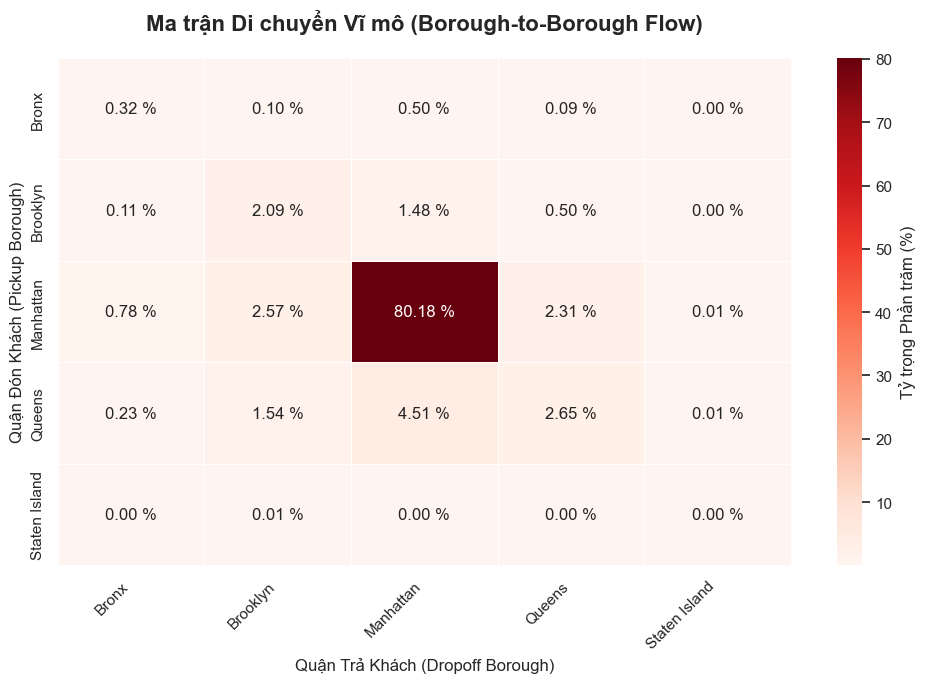

In [5]:
print("--- KHỐI 4 (BONUS): LUỒNG DI CHUYỂN CẤP ĐỘ QUẬN (BOROUGH-LEVEL) ---")

# 1. Lọc bỏ các giá trị nhiễu (Unknown) để tập trung vào 5 Quận chính của New York
valid_boroughs = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island']
borough_df = df[(df['pu_Borough'].isin(valid_boroughs)) & (df['do_Borough'].isin(valid_boroughs))]

# 2. Nhóm dữ liệu và đếm số chuyến xe giữa các Quận
borough_matrix = borough_df.groupby(['pu_Borough', 'do_Borough']).size().reset_index(name='trips')

# 3. Chuyển thành bảng ma trận 2 chiều (Pivot)
borough_pivot = borough_matrix.pivot(index='pu_Borough', columns='do_Borough', values='trips').fillna(0)

# 4. Tính tỷ trọng Phần trăm (%) để dễ dàng so sánh quy mô
total_valid_trips = borough_pivot.values.sum()
borough_pct = (borough_pivot / total_valid_trips) * 100

# 5. Vẽ Bản đồ nhiệt (Heatmap)
plt.figure(figsize=(10, 7))
sns.heatmap(borough_pct, cmap='Reds', annot=True, fmt='.2f', linewidths=.5, 
            cbar_kws={'label': 'Tỷ trọng Phần trăm (%)'})
plt.title('Ma trận Di chuyển Vĩ mô (Borough-to-Borough Flow)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Quận Trả Khách (Dropoff Borough)', fontsize=12)
plt.ylabel('Quận Đón Khách (Pickup Borough)', fontsize=12)

# Thêm ký hiệu % vào các con số trong ô cho chuyên nghiệp
ax = plt.gca()
for t in ax.texts:
    t.set_text(t.get_text() + " %")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **📝 Góc nhìn Vĩ mô (Macro Business Insights):**
> 
> **1. Quyền lực tuyệt đối của Manhattan:** 
> Nhìn vào ma trận, có tới **80.18%** tổng số cuốc xe Yellow Taxi chỉ quẩn quanh bên trong nội bộ quận Manhattan. Điều này minh chứng rằng Yellow Taxi gần như phục vụ độc quyền cho giới nhà giàu, dân văn phòng và khách du lịch tại khu vực đắt đỏ nhất hành tinh này, bỏ ngỏ hoàn toàn các quận khác như Bronx hay Staten Island (tỷ lệ gần như bằng 0%).
> 
> **2. Bức tranh Sân bay được tái hiện hoàn hảo:**
> Bạn có thấy ô **Queens -> Manhattan** (4.51%) cao gấp đôi ô **Manhattan -> Queens** (2.31%) không? Cả 2 sân bay lớn nhất (JFK và LaGuardia) đều nằm ở quận Queens! 
> Sự chênh lệch (4.51% vs 2.31%) ở góc độ Quận này khớp chính xác 100% với hiện tượng *"Cán cân Sân bay lệch pha"* mà chúng ta phát hiện ở Khối 4 (Khách thích gọi taxi từ Sân bay về, nhưng lúc ra Sân bay lại lười gọi).
> 
> **3. Cơ hội Chiến lược (Recommendation):**
> Manhattan hiện tại đã là một "Đại dương đỏ" chật chội và tắc nghẽn. Nếu công ty muốn tung ra một chiến dịch Khuyến mãi (Promotion Experiment), thay vì đốt tiền giảm giá ở Manhattan, hãy nhắm vào luồng di chuyển **Manhattan -> Brooklyn** (2.57%) hoặc **Nội bộ Brooklyn** (2.09%). Đây là một "Đại dương xanh" với tệp khách hàng trẻ, năng động và tiềm năng tăng trưởng khổng lồ.


# 5. Sự dịch chuyển dòng người ngày và đêm

--- KHỐI 5 (ULTIMATE BONUS): SỰ DỊCH CHUYỂN DÒNG NGƯỜI (DAY VS NIGHT) ---


C:\Users\minhh\AppData\Local\Temp\ipykernel_27716\3973133764.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_morning, y='Pickup Zone', x='Số lượng chuyến', ax=ax[0], palette='Blues_r')
C:\Users\minhh\AppData\Local\Temp\ipykernel_27716\3973133764.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_night, y='Pickup Zone', x='Số lượng chuyến', ax=ax[1], palette='Oranges_r')


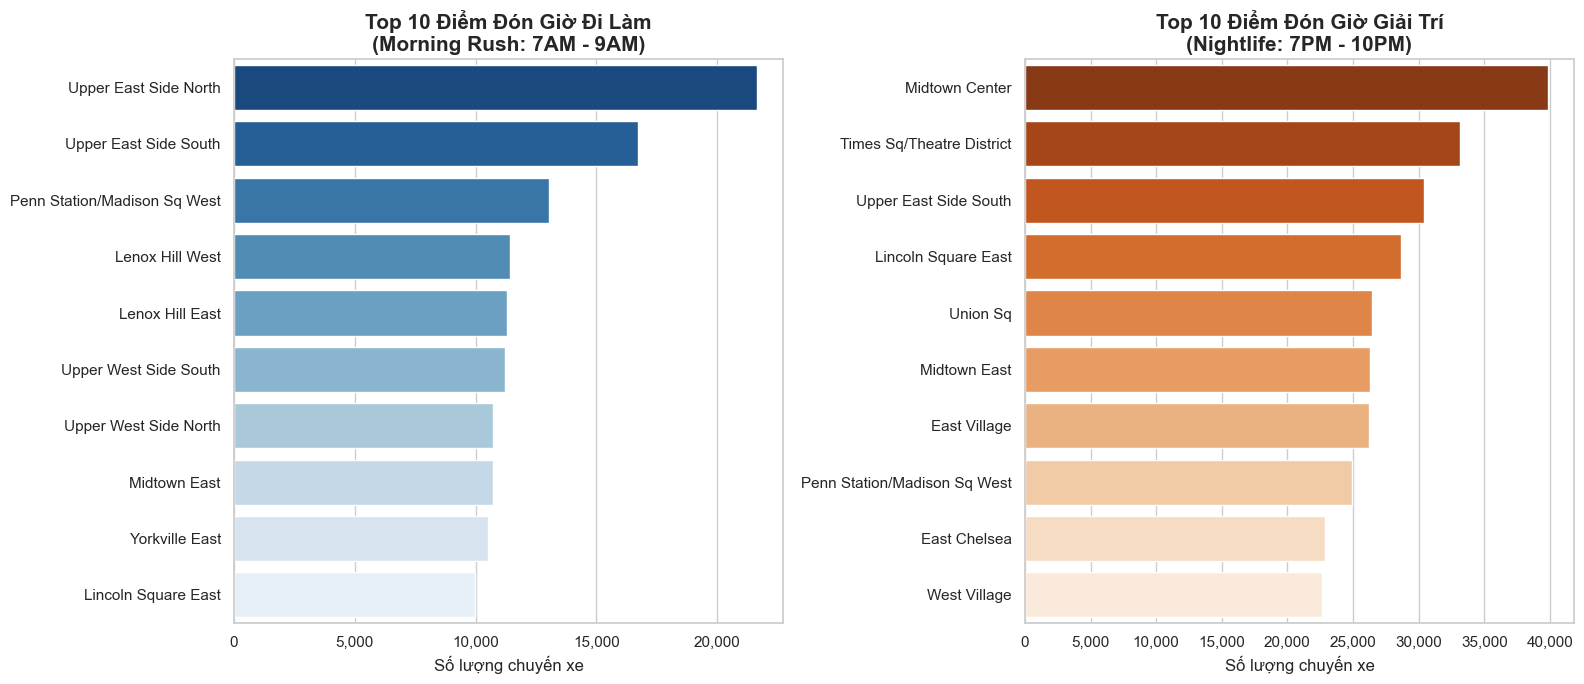

In [6]:
print("--- KHỐI 5 (ULTIMATE BONUS): SỰ DỊCH CHUYỂN DÒNG NGƯỜI (DAY VS NIGHT) ---")

# 0. Tạo cột giờ đón khách (Vì cột này chưa có sẵn trong file dữ liệu gốc ở Task 3)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# 1. Lọc dữ liệu theo 2 khung giờ Vàng (Bỏ qua những cuốc xe Sân bay để tập trung vào Nội đô)
city_df = df[df['trip_type'] == 'Nội đô (City)']

morning_rush = city_df[(city_df['pickup_hour'] >= 7) & (city_df['pickup_hour'] <= 9)]
night_life = city_df[(city_df['pickup_hour'] >= 19) & (city_df['pickup_hour'] <= 22)]

# 2. Lấy Top 10 Điểm Đón Khách cho mỗi khung giờ
top10_morning = morning_rush['pu_Zone'].value_counts().head(10).reset_index()
top10_morning.columns = ['Pickup Zone', 'Số lượng chuyến']

top10_night = night_life['pu_Zone'].value_counts().head(10).reset_index()
top10_night.columns = ['Pickup Zone', 'Số lượng chuyến']

# 3. Vẽ biểu đồ so sánh (Màu Xanh cho buổi sáng, Màu Cam/Đỏ cho buổi tối)
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ Sáng (Morning Rush)
sns.barplot(data=top10_morning, y='Pickup Zone', x='Số lượng chuyến', ax=ax[0], palette='Blues_r')
ax[0].set_title('Top 10 Điểm Đón Giờ Đi Làm\n(Morning Rush: 7AM - 9AM)', fontsize=15, fontweight='bold')
ax[0].set_xlabel('Số lượng chuyến xe', fontsize=12)
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Biểu đồ Tối (Nightlife)
sns.barplot(data=top10_night, y='Pickup Zone', x='Số lượng chuyến', ax=ax[1], palette='Oranges_r')
ax[1].set_title('Top 10 Điểm Đón Giờ Giải Trí\n(Nightlife: 7PM - 10PM)', fontsize=15, fontweight='bold')
ax[1].set_xlabel('Số lượng chuyến xe', fontsize=12)
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()



> **📝 Góc nhìn Vận hành (Actionable Insights cho Tài xế & Điều phối viên):**
> 
> **1. Quy mô thị trường: Đêm "ăn đứt" Ngày (Volume Shift)**
> Hãy nhìn kỹ vào trục hoành (trục X) của 2 biểu đồ! Vào buổi sáng, điểm nóng nhất (Upper East Side North) chỉ đạt khoảng **21,000** chuyến. Nhưng vào buổi tối, đỉnh điểm (Midtown Center) vọt lên tới tận **40,000** chuyến (gấp đôi!). 
> => **Insight:** Dân New York thích đi Tàu điện ngầm (Subway) đi làm vào buổi sáng để tránh tắc đường, nhưng khi màn đêm buông xuống, họ lại chuộng đi Taxi vàng để đi chơi, dự tiệc hoặc về nhà. Nhu cầu gọi xe buổi tối bùng nổ dữ dội hơn hẳn ban ngày.
> 
> **2. Sự dịch chuyển Không gian (Spatial Shift): Dân cư vs. Giải trí**
> * **Buổi sáng (7h - 9h):** Top 10 Điểm đón bị thống trị hoàn toàn bởi các **Khu Dân cư (Residential Areas)** ở phía Bắc Manhattan như: *Upper East Side (North/South), Upper West Side (North/South), Lenox Hill, Yorkville*. Dòng người ồ ạt rời khỏi căn hộ của mình để bắt đầu ngày mới.
> * **Buổi tối (19h - 22h):** Tâm điểm dịch chuyển mạnh mẽ về phía Nam, nhường chỗ cho các **Tụ điểm Thương mại & Giải trí (Commercial & Entertainment)** như: *Midtown Center (văn phòng), Times Sq/Theatre District (du lịch, nhạc kịch), East/West Village, Union Sq (quán bar, nhà hàng)*. Dòng người lúc này tan làm đi nhậu, hoặc ăn chơi xong gọi xe đi về.
> 
> **3. Lời khuyên vàng cho Tài xế (Recommendation):**
> Đừng lái xe vô định! 
> * Sáng sớm thức dậy, hãy đánh xe ngay lên mạn Bắc Manhattan (khu Upper) chốt chặn ở các sảnh chung cư cao cấp. 
> * Nhưng từ 6h tối trở đi, tuyệt đối phải dồn xe về mạn Nam (khu Midtown, Times Square, các phố Village) để đón khách đi quẩy. Đi đúng luồng này, doanh thu của tài xế chắc chắn sẽ tăng vọt!
